# 🏋️ Biomechanical 3D Squat Analysis Pipeline

This notebook processes raw 2D video of squats and extracts broadcast-quality, anatomically accurate 3D joint angles using a stateless tracking approach and a Dual-stream Spatio-temporal Transformer (MotionBERT).

**Pipeline Architecture:**
1. **Extraction:** YOLOv8 (Stateless + Center-Weighted Attention) extracts 2D COCO keypoints.
2. **Transformation (Healing):** Pandas performs time-series imputation to heal missing bounding box data.
3. **3D Lifting:** MotionBERT (DSTformer) calculates Z-axis depth using AMASS kinematic pre-training.
4. **Biomechanical Calculation:** 3D coordinates are converted into physical joint angles (degrees) via vector dot products.

# STEP 1: ENVIRONMENT & GLOBAL CONFIGURATION

In [9]:
# ==========================================
# STEP 1: ENVIRONMENT & GLOBAL CONFIGURATION
# ==========================================

!pip install --quiet --no-warn-script-location ultralytics opencv-python-headless numpy torch torchvision fastdtw transformers lapx pandas matplotlib

import sys
import os
import json
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO
from tqdm.auto import tqdm
import shutil
from google.colab import drive
import subprocess
import datetime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

# --- GLOBAL PIPELINE FILTER ---
# Add specific filenames here to only process those videos (e.g., ["anatomy.mp4", "IMG_123.MOV"]).
# Leave the list empty [] to process ALL videos in the input directories.
TARGET_VIDEOS = []

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# ---------------------------------------------------------
# DIRECTORY SETUP
# ---------------------------------------------------------
BASE_PATH = Path("/content/drive/MyDrive/ITCS 4152 5010")

input_dir = BASE_PATH / "Data"
output_video_dir = BASE_PATH / "outputs/annotate_videos"
output_keypoint_dir = BASE_PATH / "outputs/keypoints"
output_standardized_dir = BASE_PATH / "outputs/standardized_2d_keypoints"
output_motionbert_dir = BASE_PATH / "outputs/motionbert_keypoints"
output_angles_dir = BASE_PATH / "outputs/angles_csv"
output_final_npy_dir = BASE_PATH / "outputs/model_ready_reps"

if not input_dir.exists():
    print(f"ERROR: Cannot find {input_dir}. Check your BASE_PATH.")

# Create directories
for d in [output_video_dir, output_keypoint_dir, output_standardized_dir, output_motionbert_dir, output_angles_dir, output_final_npy_dir]:
    d.mkdir(parents=True, exist_ok=True)

# Clone & Setup MotionBERT
if not os.path.exists('/content/MotionBERT'):
    !git clone https://github.com/Walter0807/MotionBERT.git
if "/content/MotionBERT" not in sys.path:
    sys.path.append("/content/MotionBERT")

# Verify GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Compute Device Active: {device}")

def log(msg):
    print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] {msg}")

Mounted at /content/drive
Compute Device Active: cuda


## Step 2: Stateless 2D Pose Extraction (YOLOv8)
This step processes the raw video frame-by-frame. It uses a **Stateless** approach (`model.predict` instead of `model.track`) paired with a center-weighted spatial scoring algorithm to prevent the bounding box from hallucinating or locking onto background gym equipment.

In [11]:
# ==========================================
# STEP 2: YOLOv8 EXTRACTION
# ==========================================

RELEVANT_FOLDERS = ["original data", "golden reference"]
yolo_model = YOLO("yolov8m-pose.pt").to(device)
VIDEO_EXTENSIONS = {".mp4", ".mov", ".avi", ".mkv"}

COCO_SKELETON = [(0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9), (6, 8), (8, 10), (5, 11), (6, 12), (11, 12), (11, 13), (13, 15), (12, 14), (14, 16)]

def get_video_fps(video_path: Path) -> float:
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    return float(fps) if fps and fps > 0 else 30.0

def compute_hard_attention_scores(xyxy, confs, width, height):
    areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
    center_x, center_y = width / 2.0, height / 2.0
    max_dist = np.sqrt(center_x**2 + center_y**2)
    box_centers_x = (xyxy[:, 0] + xyxy[:, 2]) / 2.0
    box_centers_y = (xyxy[:, 1] + xyxy[:, 3]) / 2.0
    distances = np.sqrt((box_centers_x - center_x)**2 + (box_centers_y - center_y)**2)
    proximity_scores = 1.0 - (distances / max_dist)
    return (areas * 0.4) * (confs * 0.2) * (proximity_scores * 0.4)

def draw_primary_subject(frame, box, keypoints_xy, keypoints_conf, min_kpt_conf):
    x1, y1, x2, y2 = box.astype(int)
    cv2.rectangle(frame, (x1, y1), (x2, y2), (60, 180, 255), 2)
    cv2.putText(frame, "Primary Subject", (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (60, 180, 255), 2, cv2.LINE_AA)
    for i, (x, y) in enumerate(keypoints_xy):
        if keypoints_conf[i] < min_kpt_conf: continue
        cv2.circle(frame, (int(x), int(y)), 4, (0, 220, 255), -1)
    for a, b in COCO_SKELETON:
        if keypoints_conf[a] < min_kpt_conf or keypoints_conf[b] < min_kpt_conf: continue
        cv2.line(frame, (int(keypoints_xy[a][0]), int(keypoints_xy[a][1])), (int(keypoints_xy[b][0]), int(keypoints_xy[b][1])), (0, 255, 80), 2)

def process_video(model, optimized_video_path, output_video_path, output_keypoint_path, conf=0.4, kpt_conf=0.4):
    all_frames = []
    frame_idx = 0
    fps = get_video_fps(optimized_video_path)
    writer = None

    results_stream = model.predict(source=str(optimized_video_path), stream=True, conf=conf, imgsz=1280, half=True, verbose=False, device=device)

    for result in results_stream:
        frame = result.orig_img.copy()
        height, width = frame.shape[:2]
        if writer is None: writer = cv2.VideoWriter(str(output_video_path), cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))

        frame_data = {"frame": frame_idx, "people": []}
        if result.boxes is not None and len(result.boxes) > 0:
            xyxy = result.boxes.xyxy.cpu().numpy()
            confs = result.boxes.conf.cpu().numpy()
            scores = compute_hard_attention_scores(xyxy, confs, width, height)
            primary_index = int(np.argmax(scores)) if scores.size > 0 else None

            if primary_index is not None and result.keypoints is not None:
                primary_box = xyxy[primary_index]
                primary_keypoints_xy = result.keypoints.xy[primary_index].cpu().numpy()
                primary_keypoints_conf = result.keypoints.conf[primary_index].cpu().numpy() if result.keypoints.conf is not None else np.ones(primary_keypoints_xy.shape[0], dtype=float)

                draw_primary_subject(frame, primary_box, primary_keypoints_xy, primary_keypoints_conf, kpt_conf)
                person_data = {"person_id": 0, "keypoints": []}
                for joint_idx in range(len(primary_keypoints_xy)):
                    person_data["keypoints"].append({"joint_id": joint_idx, "x": float(primary_keypoints_xy[joint_idx][0]), "y": float(primary_keypoints_xy[joint_idx][1]), "confidence": float(primary_keypoints_conf[joint_idx])})
                frame_data["people"].append(person_data)

        if writer is not None: writer.write(frame)
        all_frames.append(frame_data)
        frame_idx += 1

    if writer is not None: writer.release()
    with output_keypoint_path.open("w", encoding="utf-8") as f: json.dump(all_frames, f, indent=2)

# --- BATCH LOOP ---
video_files = [p for p in input_dir.rglob("*") if p.suffix.lower() in VIDEO_EXTENSIONS and p.parent.name in RELEVANT_FOLDERS]
if TARGET_VIDEOS: video_files = [p for p in video_files if p.name in TARGET_VIDEOS]

target_stems = [f"{p.parent.name.lower()}__{p.stem}" for p in video_files]

log(f"Found {len(video_files)} videos. Starting pipeline...")
for video_path in tqdm(video_files, desc="YOLO Extraction"):
    stem = f"{video_path.parent.name.lower()}__{video_path.stem}"
    output_keypoint_path = output_keypoint_dir / f"{stem}_keypoints.json"
    output_video_path = output_video_dir / f"{stem}_annotated.mp4"

    local_video_path = f"/content/temp_{video_path.name}"
    optimized_video_path = f"/content/optimized_{video_path.stem}.mp4"
    shutil.copy(video_path, local_video_path)

    try:
        subprocess.run(["ffmpeg", "-y", "-i", local_video_path, "-vf", "scale=-2:720", "-r", "15", "-c:v", "libx264", "-preset", "ultrafast", "-an", optimized_video_path], check=True, capture_output=True, text=True, timeout=300)
    except Exception as e:
        log(f" !! FFMPEG FAILED: {stem}")
        if os.path.exists(local_video_path): os.remove(local_video_path)
        continue

    process_video(yolo_model, Path(optimized_video_path), output_video_path, output_keypoint_path, conf=0.4, kpt_conf=0.4)
    os.remove(local_video_path)
    os.remove(optimized_video_path)

[02:56:47] Found 24 videos. Starting pipeline...


YOLO Extraction:   0%|          | 0/24 [00:00<?, ?it/s]

## Step 3: Data Healing & Standardization (Pandas Imputation)
Because YOLO is a 2D bounding box model, it occasionally misses body parts due to background camouflage or clothing (e.g., chopping off the head). This step reads the raw JSON, identifies missing joints using the confidence score, and uses Pandas time-series interpolation to heal the gaps before saving the data as a clean 3D Tensor `(Time, 17, 3)`.

In [12]:
# ==========================================
# STEP 3: PANDAS IMPUTATION
# ==========================================

json_files = list(output_keypoint_dir.rglob("*.json"))
if 'target_stems' in globals() and target_stems:
    json_files = [p for p in json_files if p.stem.replace("_keypoints", "") in target_stems]

print(f"Found {len(json_files)} targeted JSON files. Healing data...")

num_joints = 17
confidence_threshold = 0.2

for j_path in json_files:
    with j_path.open("r", encoding="utf-8") as f:
        frames = json.load(f)

    T = len(frames)
    if T == 0: continue

    sequence_array = np.full((T, num_joints, 3), np.nan, dtype=np.float32)

    for t, frame in enumerate(frames):
        people = frame.get("people", [])
        if people and people[0].get("person_id") == 0:
            for joint in people[0].get("keypoints", []):
                j_id, conf = int(joint.get("joint_id", -1)), float(joint.get("confidence", 0.0))
                if 0 <= j_id < num_joints and conf >= confidence_threshold:
                    sequence_array[t, j_id, 0] = joint.get("x", np.nan)
                    sequence_array[t, j_id, 1] = joint.get("y", np.nan)
                    sequence_array[t, j_id, 2] = conf

    # Time-series healing
    for j_id in range(num_joints):
        df = pd.DataFrame(sequence_array[:, j_id, :2], columns=['x', 'y'])
        df = df.interpolate(method='linear', limit_direction='both').bfill().ffill()
        sequence_array[:, j_id, 0], sequence_array[:, j_id, 1] = df['x'].values, df['y'].values
        sequence_array[np.isnan(sequence_array[:, j_id, 2]), j_id, 2] = 0.5

    np.save(output_standardized_dir / f"{j_path.stem}.npy", np.nan_to_num(sequence_array, nan=0.0))

Found 24 targeted JSON files. Healing data...


## Step 4: MotionBERT 3D Lifting (DSTformer)
This step replaces standard 2D-to-3D math with a Dual-stream Spatio-temporal Transformer. Because MotionBERT was pre-trained on millions of frames of dynamic human motion (AMASS), it contains a strong kinematic prior. It calculates the Z-axis depth accurately by interpreting the momentum and foreshortening of the YOLO 2D coordinates.

In [13]:
# ==========================================
# STEP 4: MOTIONBERT INFERENCE
# ==========================================

from lib.model.DSTformer import DSTformer

WEIGHTS_FILE_NAME = "MB_ft_h36m.bin"
weights_path = BASE_PATH / "Data" / WEIGHTS_FILE_NAME

npy_files = list(output_standardized_dir.rglob("*.npy"))
if 'target_stems' in globals() and target_stems:
    npy_files = [p for p in npy_files if p.stem.replace("_keypoints", "") in target_stems]

motionbert_model = DSTformer(dim_in=3, dim_out=3, dim_feat=512, dim_rep=512, depth=5, num_heads=8, mlp_ratio=2, maxlen=243, num_joints=17).to(device)
checkpoint = torch.load(weights_path, map_location=device, weights_only=False)
motionbert_model.load_state_dict({k.replace('module.', ''): v for k, v in checkpoint.get('model_pos', checkpoint.get('model', checkpoint)).items()}, strict=False)
motionbert_model.eval()

def convert_coco_to_h36m(coco_points):
    T = coco_points.shape[0]
    h36m = np.zeros((T, 17, 3), dtype=np.float32)
    h36m[:, 1], h36m[:, 2], h36m[:, 3] = coco_points[:, 12], coco_points[:, 14], coco_points[:, 16]
    h36m[:, 4], h36m[:, 5], h36m[:, 6] = coco_points[:, 11], coco_points[:, 13], coco_points[:, 15]
    h36m[:, 9], h36m[:, 11], h36m[:, 12] = coco_points[:, 0], coco_points[:, 5], coco_points[:, 7]
    h36m[:, 13], h36m[:, 14], h36m[:, 15], h36m[:, 16] = coco_points[:, 9], coco_points[:, 6], coco_points[:, 8], coco_points[:, 10]
    h36m[:, 0] = (coco_points[:, 11] + coco_points[:, 12]) / 2.0
    h36m[:, 8] = (coco_points[:, 5] + coco_points[:, 6]) / 2.0
    h36m[:, 7] = (h36m[:, 0] + h36m[:, 8]) / 2.0
    h36m[:, 10] = h36m[:, 9] + (h36m[:, 9] - h36m[:, 8]) * 0.2
    return h36m

for npy_path in tqdm(npy_files, desc="MotionBERT Inference"):
    h36m_2d = convert_coco_to_h36m(np.load(npy_path))
    for t in range(h36m_2d.shape[0]): h36m_2d[t, :, :2] = (h36m_2d[t, :, :2] - h36m_2d[t, 0, :2].copy()) / 1000.0

    padded_2d = np.concatenate([np.repeat(h36m_2d[0:1], 121, axis=0), h36m_2d, np.repeat(h36m_2d[-1:], 121, axis=0)], axis=0)
    predicted_3d_frames = []

    for i in range(h36m_2d.shape[0]):
        window = torch.tensor(padded_2d[i : i + 243], dtype=torch.float32).unsqueeze(0).contiguous().to(device)
        with torch.no_grad():
            out_3d = motionbert_model(window).squeeze().cpu().numpy()
        predicted_3d_frames.append(out_3d[121] if len(out_3d.shape) == 3 else out_3d)

    np.save(output_motionbert_dir / npy_path.name, np.stack(predicted_3d_frames, axis=0))

MotionBERT Inference:   0%|          | 0/24 [00:00<?, ?it/s]

## Step 6: Extract Joint Angles (The Handoff)
Converts the final 3D root-relative vectors into real-world angles (in degrees) for the final PyTorch comparison model.

In [14]:
# ==========================================
# STEP 5: ANGLE EXTRACTION (CSV MAPS)
# ==========================================

angle_npy_files = list(output_motionbert_dir.rglob("*.npy"))
if 'target_stems' in globals() and target_stems:
    angle_npy_files = [p for p in angle_npy_files if p.stem.replace("_keypoints", "") in target_stems]

ANGLE_TRIPLETS = {
    "Right_Knee": (1, 2, 3), "Left_Knee": (4, 5, 6),
    "Right_Hip": (7, 1, 2), "Left_Hip": (7, 4, 5), "Spine_Lean": (8, 7, 0)
}

def calc_angles(seq, a, b, c):
    BA, BC = seq[:, a, :] - seq[:, b, :], seq[:, c, :] - seq[:, b, :]
    cosine_angle = np.clip(np.sum(BA * BC, axis=1) / (np.maximum(np.linalg.norm(BA, axis=1), 1e-6) * np.maximum(np.linalg.norm(BC, axis=1), 1e-6)), -1.0, 1.0)
    return np.degrees(np.arccos(cosine_angle))

for npy_path in tqdm(angle_npy_files, desc="Calculating Angles"):
    seq_3d = np.load(npy_path)
    df_angles = pd.DataFrame({"Frame": np.arange(seq_3d.shape[0]), **{name: calc_angles(seq_3d, a, b, c) for name, (a, b, c) in ANGLE_TRIPLETS.items()}})
    df_angles.to_csv(output_angles_dir / f"{npy_path.stem.replace('_keypoints', '')}_angles.csv", index=False)

Calculating Angles:   0%|          | 0/24 [00:00<?, ?it/s]

In [30]:
# ==========================================
# STEP 6: DYNAMIC TIME WARPING & AUGMENTATION
# ==========================================

csv_files = list(output_angles_dir.rglob("*.csv"))
TARGET_JOINTS = [2, 5, 1, 4, 7, 3, 6] # R_Knee, L_Knee, R_Hip, L_Hip, Spine
TARGET_FRAMES = 41
GOLDEN_AUGMENT_COUNT = 10

def get_dynamic_bounds(knee_angles, hole_idx, max_search=45):
    left_bound = max(0, hole_idx - max_search)
    right_bound = min(len(knee_angles), hole_idx + max_search + 1)
    return left_bound + np.argmax(knee_angles[left_bound:hole_idx+1]), hole_idx + np.argmax(knee_angles[hole_idx:right_bound])

def extract_and_warp_3d(sequence_3d, start_idx, end_idx):
    raw_slice_3d = sequence_3d[start_idx:end_idx+1, TARGET_JOINTS, :]
    if raw_slice_3d.shape[0] < 2: return None
    return interp1d(np.linspace(0, 1, raw_slice_3d.shape[0]), raw_slice_3d, axis=0, kind='linear')(np.linspace(0, 1, TARGET_FRAMES))

rep_counter = 0

for csv_path in csv_files:
    is_golden = "golden reference" in csv_path.stem.lower()
    label = 1 if is_golden else 0
    df = pd.read_csv(csv_path)
    if df.empty: continue

    stem_name = csv_path.stem.replace("_angles", "")
    motionbert_path = output_motionbert_dir / f"{stem_name}_keypoints.npy"
    if not motionbert_path.exists(): continue

    sequence_3d = np.load(motionbert_path)
    peaks, _ = find_peaks(-df['Right_Knee'].values, distance=30, prominence=20)

    for hole_idx in peaks:
        start_idx, end_idx = get_dynamic_bounds(df['Right_Knee'].values, hole_idx)
        base_rep_3d = extract_and_warp_3d(sequence_3d, start_idx, end_idx)
        if base_rep_3d is None or (np.max(df['Right_Knee'].values[start_idx:end_idx+1]) - np.min(df['Right_Knee'].values[start_idx:end_idx+1])) < 40.0: continue

        np.save(output_final_npy_dir / f"{stem_name}__hole_{hole_idx}__label_{label}.npy", base_rep_3d)
        rep_counter += 1

        if is_golden:
            for _ in range(GOLDEN_AUGMENT_COUNT):
                warped_rep_3d = extract_and_warp_3d(sequence_3d, max(0, start_idx + np.random.randint(-5, 6)), min(sequence_3d.shape[0]-1, end_idx + np.random.randint(-5, 6)))
                if warped_rep_3d is not None:
                    np.save(output_final_npy_dir / f"{stem_name}__hole_{hole_idx}__label_{label}_aug_{rep_counter}.npy", warped_rep_3d + np.random.normal(0, 0.01, warped_rep_3d.shape))
                    rep_counter += 1

print(f"\n✅ Extracted {rep_counter} model-ready (41, 7, 3) SPATIAL tensors to {output_final_npy_dir}")


✅ Extracted 131 model-ready (41, 7, 3) SPATIAL tensors to /content/drive/MyDrive/ITCS 4152 5010/outputs/model_ready_reps


## Step 5: Diagnostic Plotting

In [32]:
import numpy as np

# Assuming tensor shape is (41, 7, 3)
# Indices based on our new TARGET_JOINTS:
# Hip = 2, Knee = 0, Ankle = 5 (Right side)

def get_knee_angle(tensor_frame):
    knee = tensor_frame[0]
    hip = tensor_frame[2]
    ankle = tensor_frame[5]

    # Create the vectors
    vector_hip = hip - knee
    vector_ankle = ankle - knee

    # Calculate Dot Product and Magnitudes
    dot_product = np.dot(vector_hip, vector_ankle)
    norm_hip = np.linalg.norm(vector_hip)
    norm_ankle = np.linalg.norm(vector_ankle)

    # Calculate Angle
    cosine_angle = dot_product / (norm_hip * norm_ankle)
    angle_radians = np.arccos(np.clip(cosine_angle, -1.0, 1.0))

    return np.degrees(angle_radians)

In [34]:
# ==========================================
# QA 1: RAW TENSOR INSPECTION
# ==========================================
import random
import numpy as np
import pandas as pd
from IPython.display import display

sample_files = list(output_final_npy_dir.glob("*.npy"))
if sample_files:
    test_tensor = np.load(sample_files[0])
    print(f"File: {sample_files[0].name}")
    print(f"Tensor Shape: {test_tensor.shape} -> (Frames, Joints, Spatial_XYZ)\n")

    print("First Frame Spatial Data (Frame 0):")

    # 1. Isolate the very first frame (Shape becomes 5 joints, 3 axes)
    frame_zero_data = test_tensor[0]

    # 2. Define exactly what the rows and columns represent
    joints = ["Right_Knee", "Left_Knee", "Right_Hip", "Left_Hip", "Spine", "Right_Ankle", "Left_Ankle"]
    axes = ["X", "Y", "Z"]

    # 3. Wrap it in a DataFrame for a clean UI
    df_display = pd.DataFrame(frame_zero_data, index=joints, columns=axes)

    # Round to 3 decimal places (millimeters)
    df_display = df_display.round(3)

    # Use display() instead of print() to trigger Colab's rich HTML table rendering
    display(df_display)

File: golden reference__G003_side__hole_19__label_1.npy
Tensor Shape: (41, 7, 3) -> (Frames, Joints, Spatial_XYZ)

First Frame Spatial Data (Frame 0):


,X,Y,Z
Right_Knee,0.038,0.150,-0.029
Left_Knee,0.036,0.132,0.106
Right_Hip,0.002,0.003,-0.048
Left_Hip,-0.002,-0.004,0.049
Spine,0.008,-0.088,-0.009
Right_Ankle,0.002,0.297,-0.014
Left_Ankle,0.020,0.268,0.171


File: golden reference__G003_side__hole_19__label_1.npy
Tensor Shape: (41, 5, 3) -> (Frames, Joints, Spatial_XYZ)

First frame Spatial Data (X, Y, Z for 5 joints):
[[      0.038        0.15      -0.029]
 [      0.036       0.132       0.106]
 [      0.002       0.003      -0.048]
 [     -0.002      -0.004       0.049]
 [      0.008      -0.088      -0.009]]


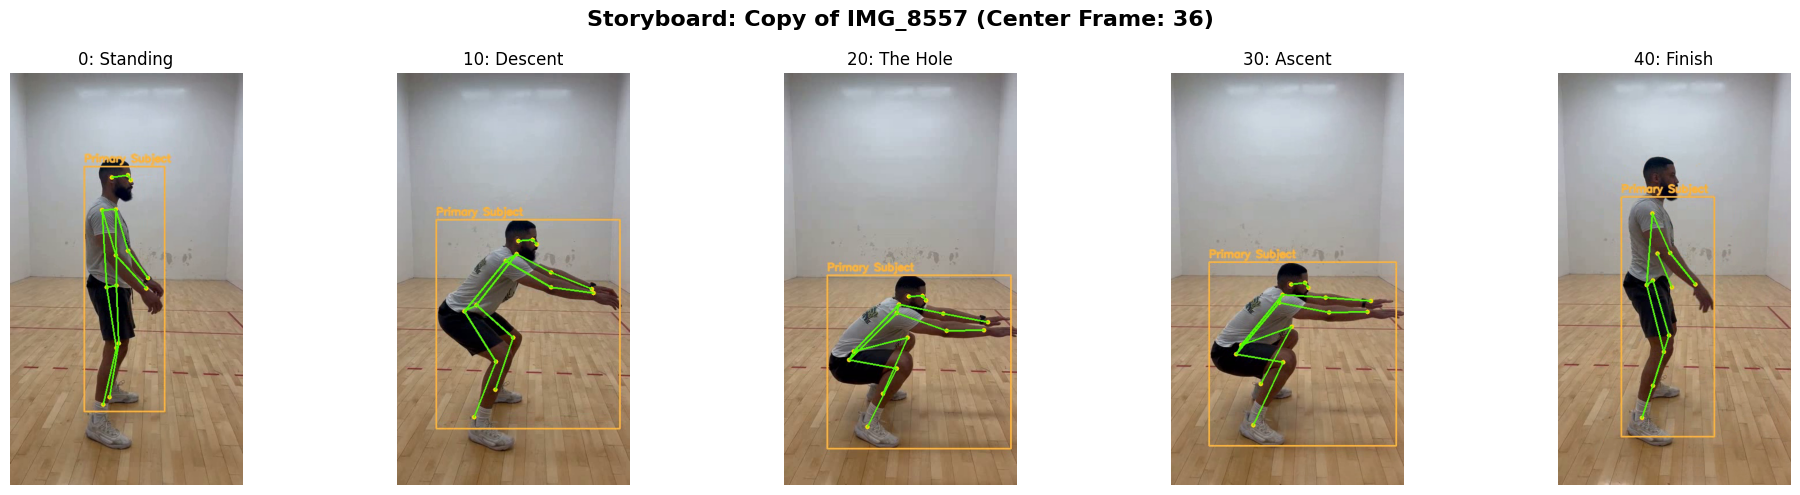

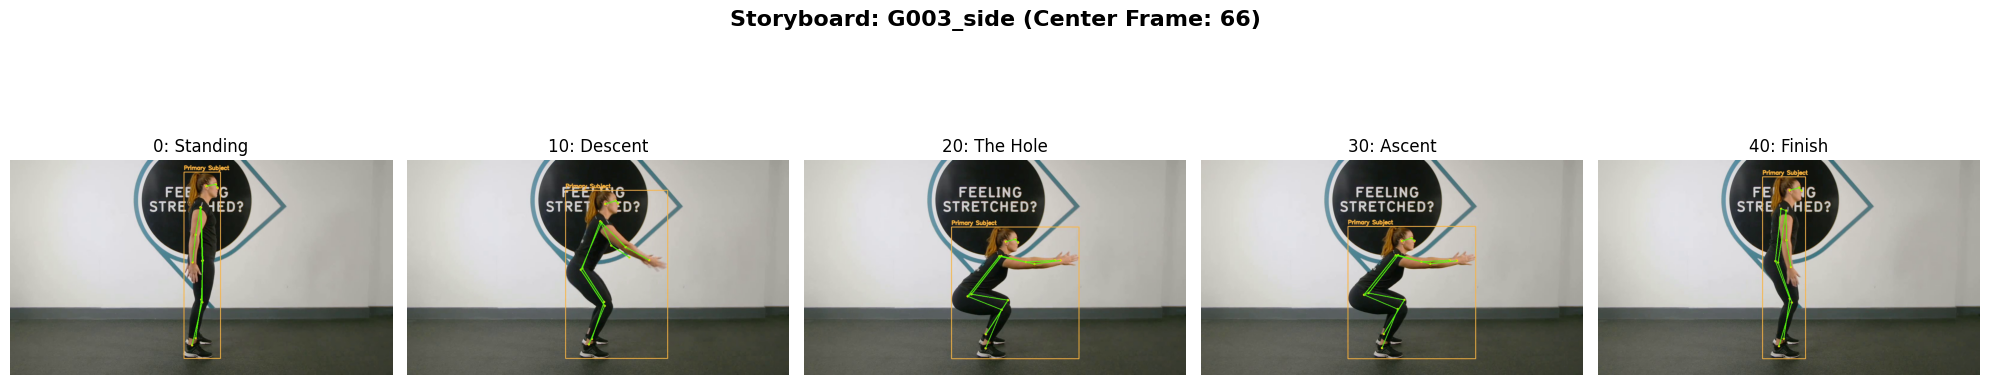

In [24]:
# ==========================================
# QA 2: STORYBOARD VISUALIZER
# ==========================================
base_reps = [f for f in output_final_npy_dir.glob("*__hole_*__label_*.npy") if "_aug_" not in f.name]
if base_reps:
    for npy_path in random.sample(base_reps, min(2, len(base_reps))):
        parts = npy_path.stem.split("__")
        video_path = output_video_dir / f"{parts[0]}__{parts[1].replace('_angles', '')}_annotated.mp4"
        hole_idx = int(parts[2].split("_")[1])

        if not video_path.exists(): continue

        cap = cv2.VideoCapture(str(video_path))
        extracted_images = []
        for f_idx in [hole_idx - 20, hole_idx - 10, hole_idx, hole_idx + 10, hole_idx + 20]:
            cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, f_idx))
            ret, frame = cap.read()
            extracted_images.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else np.zeros((720, 1280, 3), dtype=np.uint8))
        cap.release()

        fig, axes = plt.subplots(1, 5, figsize=(20, 5))
        fig.suptitle(f"Storyboard: {parts[1]} (Center Frame: {hole_idx})", fontsize=16, fontweight='bold')
        for i, (ax, img, title) in enumerate(zip(axes, extracted_images, ["0: Standing", "10: Descent", "20: The Hole", "30: Ascent", "40: Finish"])):
            ax.imshow(img); ax.set_title(title, fontsize=12); ax.axis('off')
            if i == 2:
                for spine in ax.spines.values(): spine.set_edgecolor('red'); spine.set_linewidth(5); spine.set_visible(True)
        plt.tight_layout(); plt.show()

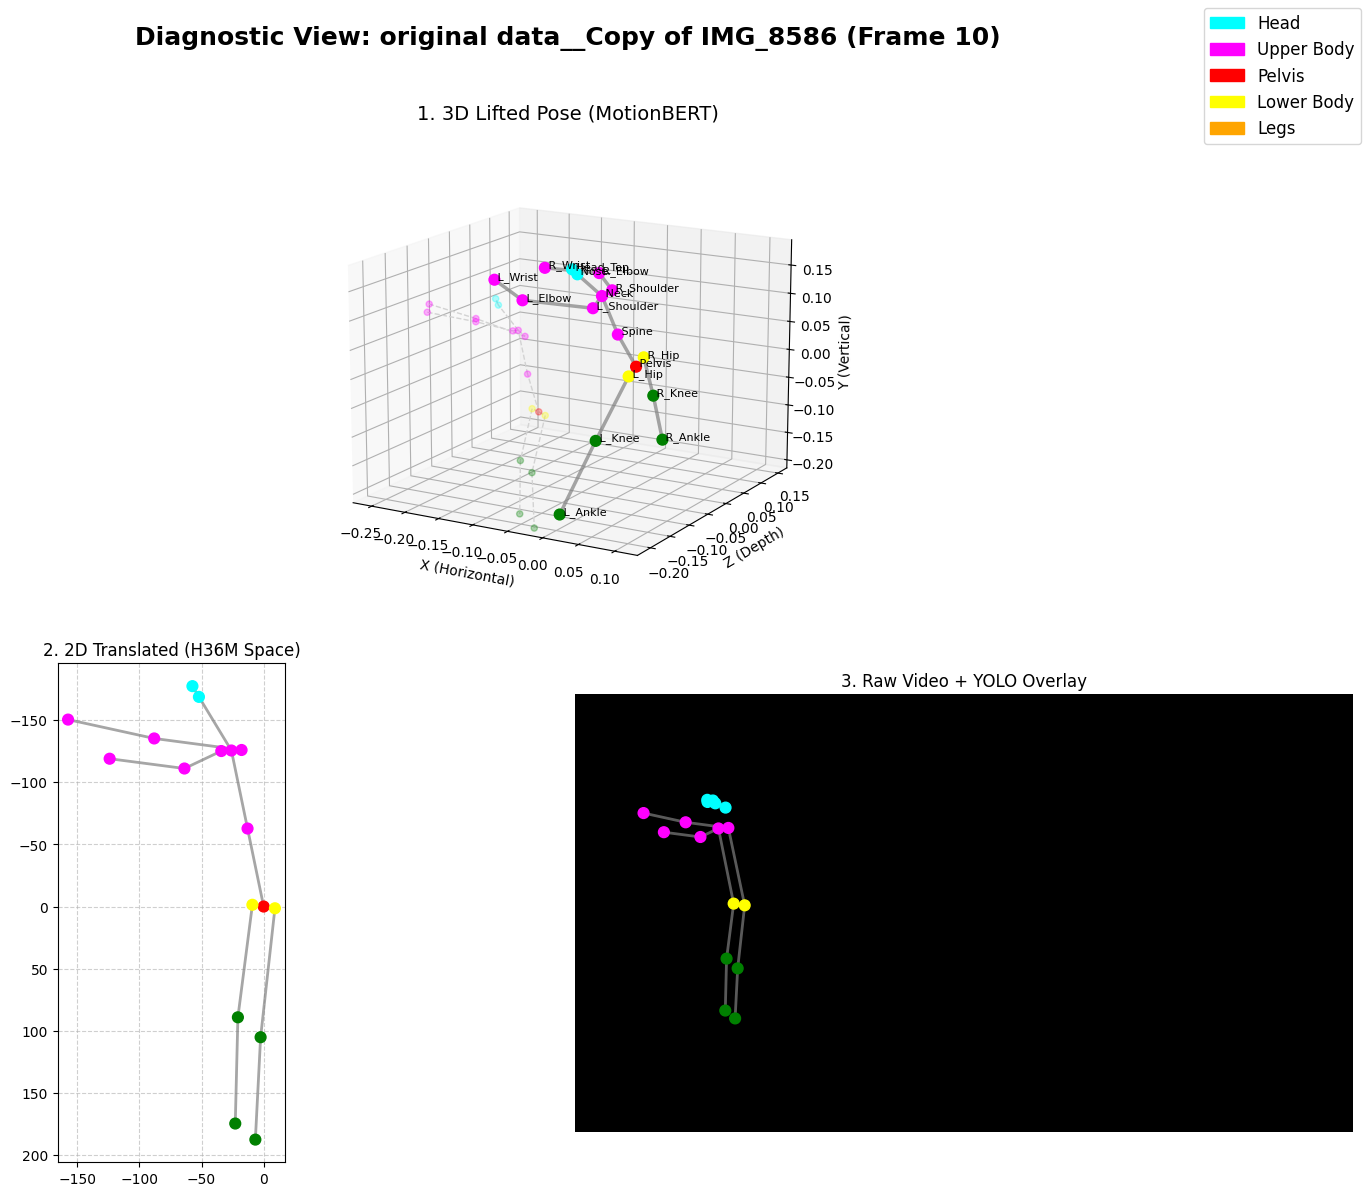

In [17]:
# Use the first target stem as our diagnostic target
DIAGNOSTIC_STEM = target_stems[10] if 'target_stems' in globals() and target_stems else "incorrect__anatomy"
FRAME_IDX = 10

video_path = BASE_PATH / "Data" / DIAGNOSTIC_STEM.split("__")[0] / f"{DIAGNOSTIC_STEM.split('__')[1]}.mp4"
standardized_2d_path = output_standardized_dir / f"{DIAGNOSTIC_STEM}_keypoints.npy"
motionbert_path = output_motionbert_dir / f"{DIAGNOSTIC_STEM}_keypoints.npy"

# Definitions & Colors
JOINT_NAMES = ["Pelvis", "R_Hip", "R_Knee", "R_Ankle", "L_Hip", "L_Knee", "L_Ankle", "Spine", "Neck", "Nose", "Head_Top", "L_Shoulder", "L_Elbow", "L_Wrist", "R_Shoulder", "R_Elbow", "R_Wrist"]
H36M_BONES = [(0, 1), (1, 2), (2, 3), (0, 4), (4, 5), (5, 6), (0, 7), (7, 8), (8, 9), (9, 10), (8, 11), (11, 12), (12, 13), (8, 14), (14, 15), (15, 16)]
COCO_BONES = [(0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9), (6, 8), (8, 10), (5, 11), (6, 12), (11, 12), (11, 13), (13, 15), (12, 14), (14, 16)]

H36M_COLORS = np.array(['gray'] * 17, dtype=object)
H36M_COLORS[[9, 10]] = 'cyan'; H36M_COLORS[[7, 8, 11, 12, 13, 14, 15, 16]] = 'magenta'
H36M_COLORS[[0]] = 'red'; H36M_COLORS[[1, 4]] = 'yellow'; H36M_COLORS[[2, 3, 5, 6]] = 'green'
COCO_COLORS = np.array(['gray'] * 17, dtype=object)
COCO_COLORS[[0, 1, 2, 3, 4]] = 'cyan'; COCO_COLORS[[5, 6, 7, 8, 9, 10]] = 'magenta'
COCO_COLORS[[11, 12]] = 'yellow'; COCO_COLORS[[13, 14, 15, 16]] = 'green'

def plot_diagnostic_3d(ax, sequence_3d, frame_idx):
    kpts = sequence_3d[frame_idx]
    width_x, height_y, depth_z = kpts[:, 0], -kpts[:, 1], kpts[:, 2] # Y-axis inverted for viewing

    ax.scatter(width_x, depth_z, height_y, c=H36M_COLORS, s=60, alpha=1.0, zorder=5)
    for joint1, joint2 in H36M_BONES: ax.plot([width_x[joint1], width_x[joint2]], [depth_z[joint1], depth_z[joint2]], [height_y[joint1], height_y[joint2]], c='gray', linewidth=2.5, alpha=0.7)
    for i, name in enumerate(JOINT_NAMES): ax.text(width_x[i], depth_z[i], height_y[i], f" {name}", size=8, color='black')

    back_wall_depth = np.min(depth_z) - (np.max(depth_z) - np.min(depth_z)) * 0.2
    ax.scatter(width_x, np.full_like(depth_z, back_wall_depth), height_y, c=H36M_COLORS, s=20, alpha=0.3)
    for joint1, joint2 in H36M_BONES: ax.plot([width_x[joint1], width_x[joint2]], [back_wall_depth, back_wall_depth], [height_y[joint1], height_y[joint2]], c='lightgray', linewidth=1, linestyle='--')

    ax.set_xlabel('X (Horizontal)'); ax.set_ylabel('Z (Depth)'); ax.set_zlabel('Y (Vertical)')
    max_range = np.array([width_x.max()-width_x.min(), depth_z.max()-depth_z.min(), height_y.max()-height_y.min()]).max() / 2.0
    mid_x, mid_depth, mid_y = (width_x.max()+width_x.min())*0.5, (depth_z.max()+depth_z.min())*0.5, (height_y.max()+height_y.min())*0.5
    margin = max_range * 1.1
    ax.set_xlim(mid_x - margin, mid_x + margin); ax.set_ylim(mid_depth - margin, mid_depth + margin); ax.set_zlim(mid_y - margin, mid_y + margin)

# Load & Prep
motionbert_data = np.load(str(motionbert_path))
standardized_sequence_2d = np.load(str(standardized_2d_path))

h36m_2d_sequence = convert_coco_to_h36m(standardized_sequence_2d)
kpts_2d_h36m = h36m_2d_sequence[FRAME_IDX]
pelvis_xy = kpts_2d_h36m[0, :2].copy()
kpts_2d_h36m[:, :2] = kpts_2d_h36m[:, :2] - pelvis_xy

cap = cv2.VideoCapture(str(video_path))
cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_IDX)
ret, frame = cap.read()
cap.release()
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else np.zeros((720, 1280, 3), dtype=np.uint8)

orig_h, orig_w = frame_rgb.shape[:2]
kpts_raw_yolo = standardized_sequence_2d[FRAME_IDX].copy()
kpts_raw_yolo[:, :2] *= (orig_h / 720.0)

# Plotting
fig = plt.figure(figsize=(16, 12))
fig.suptitle(f"Diagnostic View: {DIAGNOSTIC_STEM} (Frame {FRAME_IDX})", fontsize=18, fontweight='bold')

ax1 = fig.add_subplot(2, 2, (1, 2), projection='3d')
plot_diagnostic_3d(ax1, motionbert_data, FRAME_IDX)
ax1.view_init(elev=15, azim=-60)
ax1.set_title("1. 3D Lifted Pose (MotionBERT)", fontsize=14)

ax2 = fig.add_subplot(2, 2, 3)
ax2.scatter(kpts_2d_h36m[:, 0], kpts_2d_h36m[:, 1], c=H36M_COLORS, s=60, zorder=5)
for joint1, joint2 in H36M_BONES: ax2.plot([kpts_2d_h36m[joint1, 0], kpts_2d_h36m[joint2, 0]], [kpts_2d_h36m[joint1, 1], kpts_2d_h36m[joint2, 1]], c='gray', linewidth=2, alpha=0.7)
ax2.invert_yaxis(); ax2.set_aspect('equal'); ax2.set_title("2. 2D Translated (H36M Space)", fontsize=12); ax2.grid(True, linestyle='--', alpha=0.6)

ax3 = fig.add_subplot(2, 2, 4)
ax3.imshow(frame_rgb)
ax3.scatter(kpts_raw_yolo[:, 0], kpts_raw_yolo[:, 1], c=COCO_COLORS, s=60, zorder=5)
for joint1, joint2 in COCO_BONES:
    if kpts_raw_yolo[joint1, 2] > 0.1 and kpts_raw_yolo[joint2, 2] > 0.1:
        ax3.plot([kpts_raw_yolo[joint1, 0], kpts_raw_yolo[joint2, 0]], [kpts_raw_yolo[joint1, 1], kpts_raw_yolo[joint2, 1]], c='gray', linewidth=2, alpha=0.7)
ax3.set_title("3. Raw Video + YOLO Overlay", fontsize=12); ax3.axis('off')

fig.legend(handles=[mpatches.Patch(color=c, label=l) for c, l in zip(['cyan','magenta','red','yellow','orange'], ['Head','Upper Body','Pelvis','Lower Body','Legs'])], loc='upper right', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

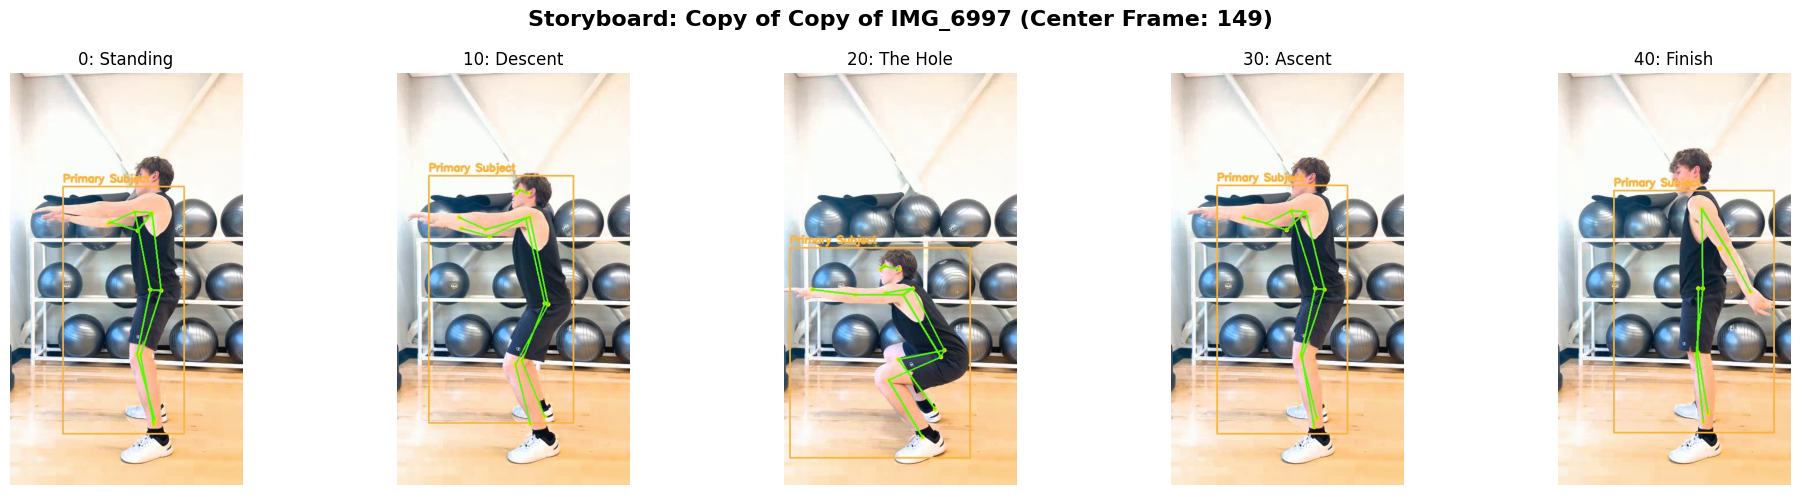

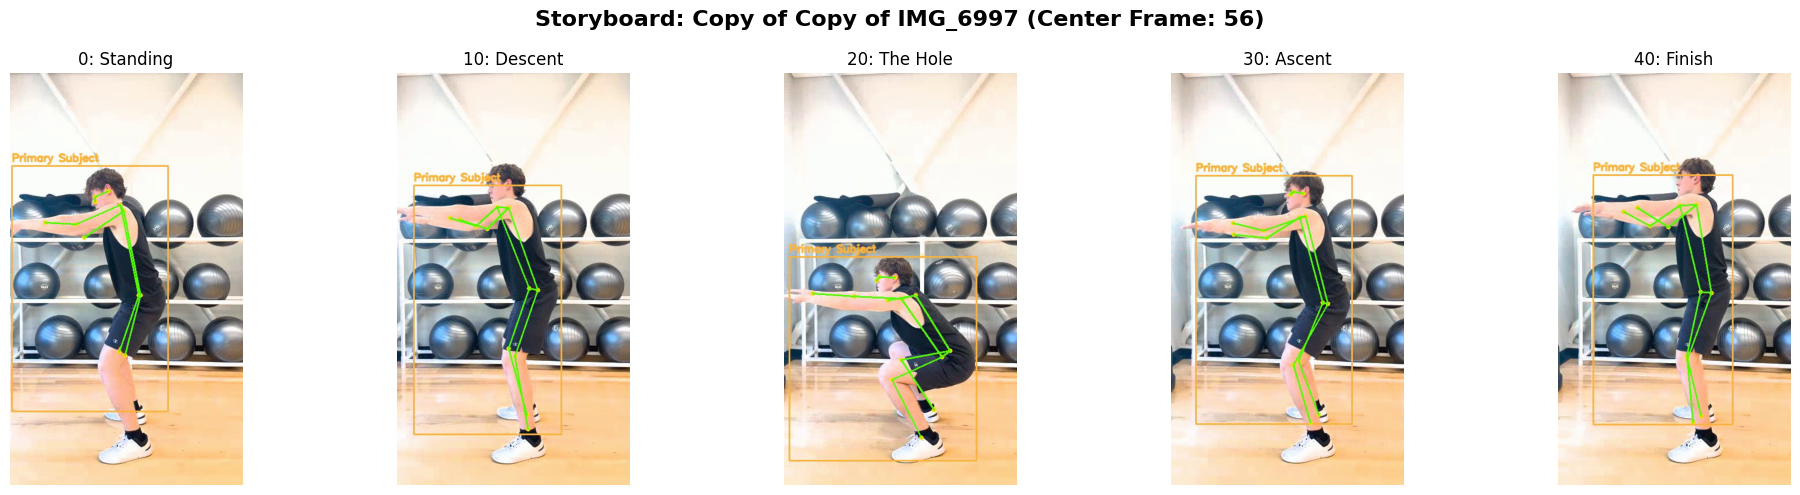

In [18]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random

output_model_ready_dir = BASE_PATH / "outputs/model_ready_reps"
# Grab only the base reps (we don't need to visualize the augmented jitter)
npy_files = list(output_model_ready_dir.glob("*__hole_*__label_*.npy"))
npy_files = [f for f in npy_files if "_aug_" not in f.name]

if not npy_files:
    print("No base rep files found. Ensure you updated the naming convention in Cell 13!")
else:
    # Pick 2 random reps to visualize
    sample_files = random.sample(npy_files, min(2, len(npy_files)))

    for npy_path in sample_files:
        # 1. Parse the Data Lineage from the filename
        # Example: correct__mindbodysoul_angles__hole_142__label_1.npy
        filename_parts = npy_path.stem.split("__")

        original_folder = filename_parts[0] # "correct" or "incorrect"
        # Remove the "_angles" suffix we added during the CSV creation
        original_video_stem = filename_parts[1].replace("_angles", "")

        # Extract the exact frame index where the bottom of the squat occurred
        hole_string = filename_parts[2] # "hole_142"
        hole_idx = int(hole_string.split("_")[1])

        # 2. Locate the 15-FPS Annotated video
        # We use the annotated video because it is strictly 15 FPS, matching the CSV rows exactly.
        annotated_video_name = f"{original_folder}__{original_video_stem}_annotated.mp4"
        video_path = output_video_dir / annotated_video_name

        if not video_path.exists():
            print(f"Could not find 15 FPS video at {video_path}")
            continue

        # 3. Extract the 5 Key Frames
        # Our 41-frame tensor is [hole - 20, hole - 10, hole, hole + 10, hole + 20]
        frame_targets = [hole_idx - 20, hole_idx - 10, hole_idx, hole_idx + 10, hole_idx + 20]
        titles = ["0: Standing", "10: Descent", "20: The Hole", "30: Ascent", "40: Finish"]

        extracted_images = []
        cap = cv2.VideoCapture(str(video_path))

        for f_idx in frame_targets:
            # Prevent seeking to negative frames if the squat happened right at the start
            safe_f_idx = max(0, f_idx)
            cap.set(cv2.CAP_PROP_POS_FRAMES, safe_f_idx)
            ret, frame = cap.read()
            if ret:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                extracted_images.append(frame_rgb)
            else:
                extracted_images.append(np.zeros((720, 1280, 3), dtype=np.uint8))

        cap.release()

        # 4. Plot the Storyboard
        fig, axes = plt.subplots(1, 5, figsize=(20, 5))
        fig.suptitle(f"Storyboard: {original_video_stem} (Center Frame: {hole_idx})", fontsize=16, fontweight='bold')

        for i, (ax, img, title) in enumerate(zip(axes, extracted_images, titles)):
            ax.imshow(img)
            ax.set_title(title, fontsize=12)
            ax.axis('off')

            # Put a red border around the center frame (The Hole)
            if i == 2:
                for spine in ax.spines.values():
                    spine.set_edgecolor('red')
                    spine.set_linewidth(5)
                    spine.set_visible(True)

        plt.tight_layout()
        plt.show()

Preparing to render 24 diagnostic videos. This may take a few minutes per video...

Rendering animation for: golden reference__G003_side...


CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1600x1200', '-pix_fmt', 'rgba', '-framerate', '24.92112728333201', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', PosixPath('/content/drive/MyDrive/ITCS 4152 5010/outputs/diagnostic_videos/golden reference__G003_side_diagnostic.mp4')]' returned non-zero exit status 255.

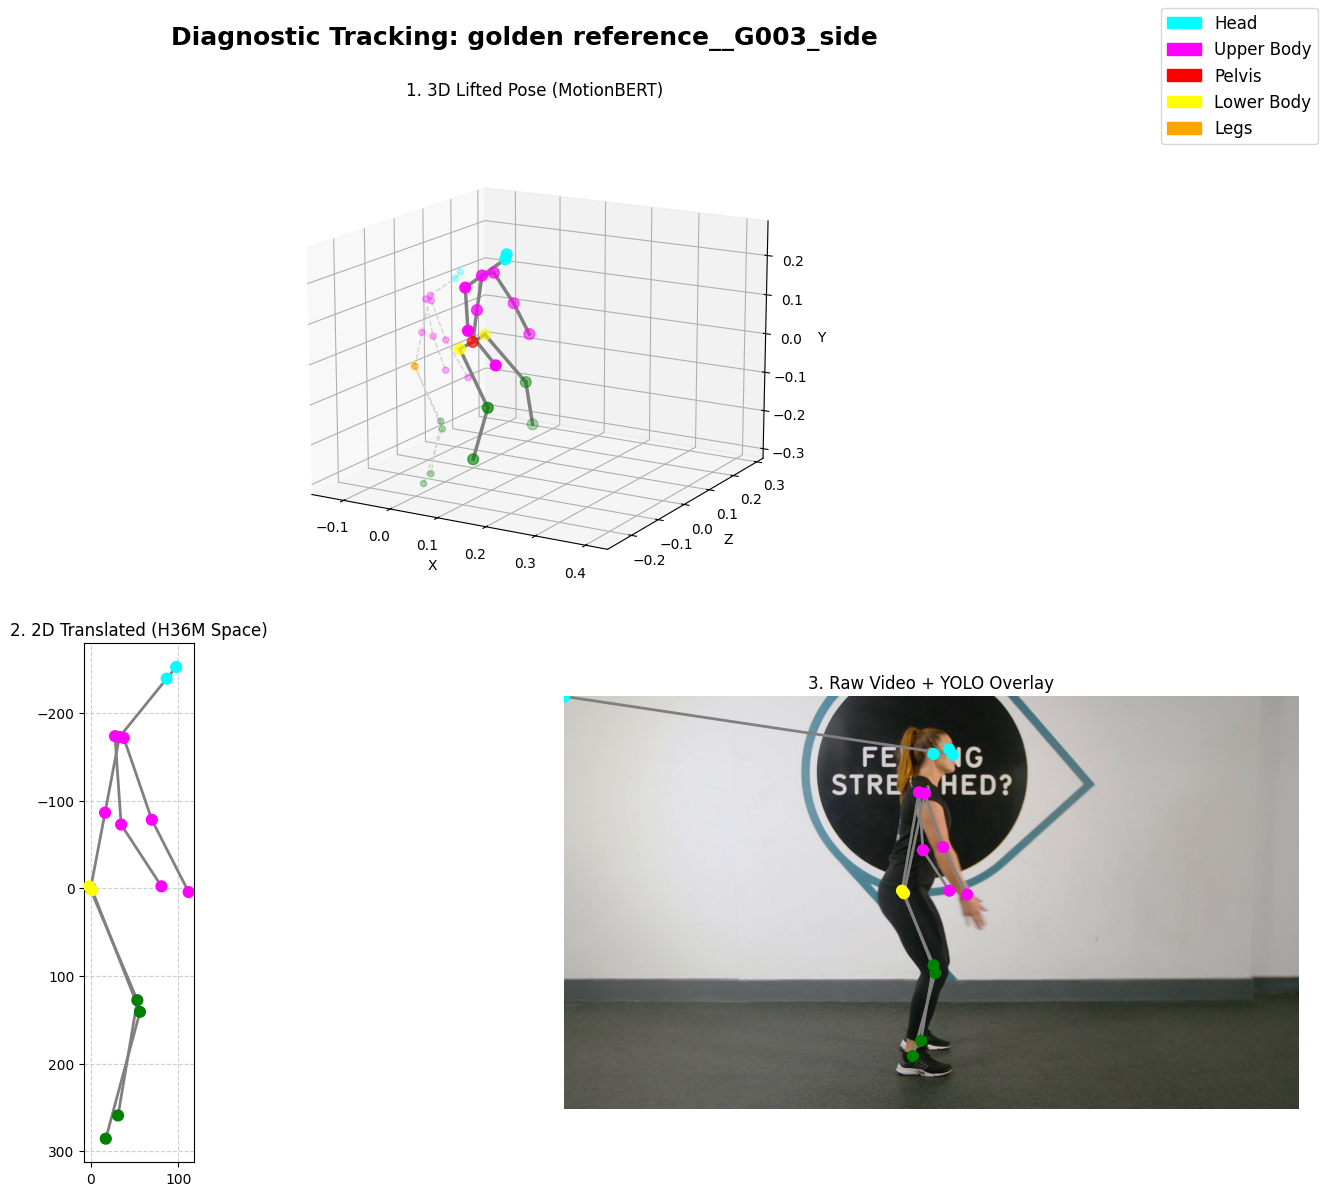

In [20]:
# Also running some diagnostic animations to showcase the model
# ==========================================
# STEP 5: ANIMATED VISUAL DIAGNOSTICS
# ==========================================

from matplotlib.animation import FuncAnimation
import matplotlib.patches as mpatches

# 1. Setup new output directory for the videos
output_diagnostic_videos_dir = BASE_PATH / "outputs/diagnostic_videos"
output_diagnostic_videos_dir.mkdir(parents=True, exist_ok=True)

# 2. Gather target files
npy_files = list(output_motionbert_dir.rglob("*.npy"))
if 'target_stems' in globals() and target_stems:
    npy_files = [p for p in npy_files if p.stem.replace("_keypoints", "") in target_stems]

print(f"Preparing to render {len(npy_files)} diagnostic videos. This may take a few minutes per video...")

# Definitions & Colors
JOINT_NAMES = ["Pelvis", "R_Hip", "R_Knee", "R_Ankle", "L_Hip", "L_Knee", "L_Ankle", "Spine", "Neck", "Nose", "Head_Top", "L_Shoulder", "L_Elbow", "L_Wrist", "R_Shoulder", "R_Elbow", "R_Wrist"]
H36M_BONES = [(0, 1), (1, 2), (2, 3), (0, 4), (4, 5), (5, 6), (0, 7), (7, 8), (8, 9), (9, 10), (8, 11), (11, 12), (12, 13), (8, 14), (14, 15), (15, 16)]
COCO_BONES = [(0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9), (6, 8), (8, 10), (5, 11), (6, 12), (11, 12), (11, 13), (13, 15), (12, 14), (14, 16)]

H36M_COLORS = np.array(['gray'] * 17, dtype=object)
H36M_COLORS[[9, 10]] = 'cyan'; H36M_COLORS[[7, 8, 11, 12, 13, 14, 15, 16]] = 'magenta'
H36M_COLORS[[0]] = 'red'; H36M_COLORS[[1, 4]] = 'yellow'; H36M_COLORS[[2, 3, 5, 6]] = 'green'

COCO_COLORS = np.array(['gray'] * 17, dtype=object)
COCO_COLORS[[0, 1, 2, 3, 4]] = 'cyan'; COCO_COLORS[[5, 6, 7, 8, 9, 10]] = 'magenta'
COCO_COLORS[[11, 12]] = 'yellow'; COCO_COLORS[[13, 14, 15, 16]] = 'green'

def create_diagnostic_animation(stem_name):
    print(f"\nRendering animation for: {stem_name}...")

    # Define paths
    original_label = stem_name.split("__")[0]
    original_name = stem_name.split("__")[1]
    video_path = BASE_PATH / "Data" / original_label / f"{original_name}.mp4"

    standardized_2d_path = output_standardized_dir / f"{stem_name}_keypoints.npy"
    motionbert_path = output_motionbert_dir / f"{stem_name}_keypoints.npy"
    output_mp4_path = output_diagnostic_videos_dir / f"{stem_name}_diagnostic.mp4"

    # Load Data
    motionbert_data = np.load(str(motionbert_path))
    standardized_sequence_2d = np.load(str(standardized_2d_path))
    h36m_2d_sequence = convert_coco_to_h36m(standardized_sequence_2d)

    T = min(motionbert_data.shape[0], h36m_2d_sequence.shape[0])

    # Video Setup
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps == 0 or np.isnan(fps): fps = 30.0

    # Calculate Global 3D Limits to lock the camera
    global_x = motionbert_data[:, :, 0]
    global_y = -motionbert_data[:, :, 1]
    global_z = motionbert_data[:, :, 2]

    max_range = np.array([global_x.max()-global_x.min(), global_z.max()-global_z.min(), global_y.max()-global_y.min()]).max() / 2.0
    mid_x = (global_x.max()+global_x.min())*0.5
    mid_z = (global_z.max()+global_z.min())*0.5
    mid_y = (global_y.max()+global_y.min())*0.5
    margin = max_range * 1.1

    # Figure Setup
    fig = plt.figure(figsize=(16, 12))
    fig.suptitle(f"Diagnostic Tracking: {stem_name}", fontsize=18, fontweight='bold')

    ax1 = fig.add_subplot(2, 2, (1, 2), projection='3d')
    ax2 = fig.add_subplot(2, 2, 3)
    ax3 = fig.add_subplot(2, 2, 4)

    # The Animation Loop
    def update(frame_idx):
        ax1.clear(); ax2.clear(); ax3.clear()

        # --- PANEL 1: 3D MotionBERT ---
        kpts_3d = motionbert_data[frame_idx]
        width_x, height_y, depth_z = kpts_3d[:, 0], -kpts_3d[:, 1], kpts_3d[:, 2]

        ax1.scatter(width_x, depth_z, height_y, c=H36M_COLORS, s=60, zorder=5)
        for j1, j2 in H36M_BONES: ax1.plot([width_x[j1], width_x[j2]], [depth_z[j1], depth_z[j2]], [height_y[j1], height_y[j2]], c='gray', linewidth=2.5)

        back_wall = global_z.min() - margin * 0.2
        ax1.scatter(width_x, np.full_like(depth_z, back_wall), height_y, c=H36M_COLORS, s=20, alpha=0.3)
        for j1, j2 in H36M_BONES: ax1.plot([width_x[j1], width_x[j2]], [back_wall, back_wall], [height_y[j1], height_y[j2]], c='lightgray', linewidth=1, linestyle='--')

        ax1.view_init(elev=15, azim=-60)
        ax1.set_xlim(mid_x - margin, mid_x + margin); ax1.set_ylim(mid_z - margin, mid_z + margin); ax1.set_zlim(mid_y - margin, mid_y + margin)
        ax1.set_xlabel('X'); ax1.set_ylabel('Z'); ax1.set_zlabel('Y'); ax1.set_title("1. 3D Lifted Pose (MotionBERT)")

        # --- PANEL 2: 2D H36M Translated ---
        kpts_2d_h36m = h36m_2d_sequence[frame_idx].copy()
        pelvis_xy = kpts_2d_h36m[0, :2].copy()
        kpts_2d_h36m[:, :2] -= pelvis_xy

        ax2.scatter(kpts_2d_h36m[:, 0], kpts_2d_h36m[:, 1], c=H36M_COLORS, s=60, zorder=5)
        for j1, j2 in H36M_BONES: ax2.plot([kpts_2d_h36m[j1, 0], kpts_2d_h36m[j2, 0]], [kpts_2d_h36m[j1, 1], kpts_2d_h36m[j2, 1]], c='gray', linewidth=2)
        ax2.invert_yaxis(); ax2.set_aspect('equal'); ax2.set_title("2. 2D Translated (H36M Space)"); ax2.grid(True, linestyle='--', alpha=0.6)

        # --- PANEL 3: Raw Video + Overlay ---
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else np.zeros((720, 1280, 3), dtype=np.uint8)
        orig_h, orig_w = frame_rgb.shape[:2]

        kpts_raw_yolo = standardized_sequence_2d[frame_idx].copy()
        kpts_raw_yolo[:, :2] *= (orig_h / 720.0)

        ax3.imshow(frame_rgb)
        ax3.scatter(kpts_raw_yolo[:, 0], kpts_raw_yolo[:, 1], c=COCO_COLORS, s=60, zorder=5)
        for j1, j2 in COCO_BONES:
            if kpts_raw_yolo[j1, 2] > 0.1 and kpts_raw_yolo[j2, 2] > 0.1:
                ax3.plot([kpts_raw_yolo[j1, 0], kpts_raw_yolo[j2, 0]], [kpts_raw_yolo[j1, 1], kpts_raw_yolo[j2, 1]], c='gray', linewidth=2)
        ax3.set_title("3. Raw Video + YOLO Overlay"); ax3.axis('off')

    # Legend
    fig.legend(handles=[mpatches.Patch(color=c, label=l) for c, l in zip(['cyan','magenta','red','yellow','orange'], ['Head','Upper Body','Pelvis','Lower Body','Legs'])], loc='upper right', fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Compile and Save
    anim = FuncAnimation(fig, update, frames=T, interval=1000/fps)
    anim.save(output_mp4_path, writer='ffmpeg', fps=fps)
    plt.close(fig)
    cap.release()
    print(f"✅ Video saved to: {output_mp4_path}")

# Run the generator
for npy_path in npy_files:
    stem_name = npy_path.stem.replace("_keypoints", "")
    create_diagnostic_animation(stem_name)

print("\n🎉 All diagnostic animations complete!")

In [ ]:
# ==========================================
# OPTIONAL: DUMP MODEL TENSORS TO CSV FOR EXCEL VIEWING
# ==========================================
import pandas as pd
import numpy as np

csv_dump_dir = BASE_PATH / "outputs/angles_csv"
csv_dump_dir.mkdir(parents=True, exist_ok=True)

final_npy_files = list(output_final_npy_dir.glob("*.npy"))
print(f"Exporting {len(final_npy_files)} tensors to CSV...")

FEATURES = ["Right_Knee", "Left_Knee", "Right_Hip", "Left_Hip", "Spine_Lean"]

for npy_path in final_npy_files:
    # Load the (41, 5) angle tensor
    tensor_data = np.load(npy_path)

    # Slap column names on it and save as CSV
    df = pd.DataFrame(tensor_data, columns=FEATURES)
    df.to_csv(csv_dump_dir / f"{npy_path.stem}.csv", index=False)

print(f"Done! Check the {csv_dump_dir} folder.")

In [ ]:
import numpy as np

# Point this to one of your actual generated files
sample_file = BASE_PATH / "outputs/model_ready_reps/original data__Copy of Copy of IMG_9978_angles__hole_23__label_0.npy"

# 1. Load the binary file into a NumPy array
tensor = np.load(sample_file)

# 2. Check the shape (It should be exactly 41, 5)
print(f"Tensor Shape: {tensor.shape} -> (Frames, Features)\n")

# 3. Print the first 5 frames
print("First 5 frames of data (Columns: R_Knee, L_Knee, R_Hip, L_Hip, Spine_Lean):")
print(np.round(tensor, 2)) # Rounded to 2 decimals for easy reading